# Lab5 Double Pendulum Experiment.

Numerical solution by Bulirsch Stoer method with Richardson extrapolation, as in the article

>Tomasz Stachowiak, Toshio Okada. A numerical analysis of chaos in the double pendulum. Chaos, Solitons
& Fractals, 2006, 29 (2), pp.417 - 422. ⟨10.1016/j.chaos.2005.08.032⟩. ⟨hal-01389907⟩

Found error in equations (2), (3)
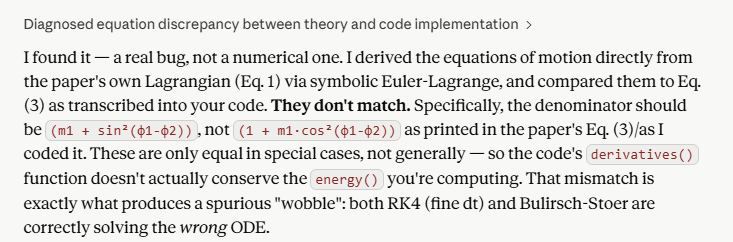

## parameters and equations of motion

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from joblib import Parallel, delayed
from scipy.integrate import solve_ivp

In [13]:
# Parameters used in the paper
m1 = 3.0
m2 = 1.0   # unit of mass
l1 = 2.0
l2 = 1.0   # unit of length
g  = 1.0   # sets unit of time

def derivatives(t, y):
    """y = [phi1, phi2, omega1, omega2], returns dy/dt.
    Corrected from Eq. 3 of Stachowiak & Okada — see note below."""
    phi1, phi2, w1, w2 = y
    dphi = phi1 - phi2
    c = np.cos(dphi)
    s = np.sin(dphi)
    denom = m1 + s**2   # NOTE: paper prints "1 + m1*cos^2(dphi)", which is
                         # inconsistent with its own Lagrangian (verified via
                         # symbolic Euler-Lagrange); this is the correct form.

    dphi1 = w1
    dphi2 = w2

    dw1 = (-s * (l1*c*w1**2 + w2**2)) / (l1*denom) \
          - ((1 + 2*m1)*np.sin(phi1) + np.sin(phi1 - 2*phi2)) / (2*l1*denom)

    dw2 = s * ((1+m1)*(np.cos(phi1) + l1*w1**2) + c*w2**2) / denom

    return np.array([dphi1, dphi2, dw1, dw2])

## modified midpoint method (the basic stepper for B-S)

In [14]:
def modified_midpoint(f, t0, y0, H, n):
    """Advance y0 by H using n substeps of the midpoint method."""
    h = H / n
    y_prev = y0.copy()
    y_curr = y0 + h * f(t0, y0)
    t = t0
    for i in range(1, n):
        t = t0 + i * h
        y_next = y_prev + 2 * h * f(t, y_curr)
        y_prev, y_curr = y_curr, y_next
    y_end = 0.5 * (y_prev + y_curr + h * f(t0 + H, y_curr))
    return y_end

## Richardson (polynomial) extrapolation and adaptive B-S step

In [15]:
def bs_step(f, t0, y0, H, tol=1e-10, n_max=16):
    """One Bulirsch-Stoer step over interval H, extrapolating in h^2."""
    n_seq = [2 * k for k in range(1, n_max + 1)]  # 2,4,6,8,...
    T = {}  # extrapolation tableau, T[i,j]

    y_extrap_prev = None
    for i, n in enumerate(n_seq):
        T[i, 0] = modified_midpoint(f, t0, y0, H, n)
        for k in range(1, i + 1):
            factor = (n_seq[i] / n_seq[i - k]) ** 2
            T[i, k] = T[i, k - 1] + (T[i, k - 1] - T[i - 1, k - 1]) / (factor - 1)

        y_extrap = T[i, i]
        if i >= 1:
            err = np.max(np.abs(y_extrap - y_extrap_prev))
            if err < tol:
                return y_extrap, err, n
        y_extrap_prev = y_extrap

    return y_extrap, err, n_seq[-1]  # did not converge to tol, return best estimate

## driver with adaptive step-size control

In [16]:
def bulirsch_stoer_integrate(y0, t_span, H0=0.05, tol=1e-10,
                              H_min=1e-6, H_max=0.5):
    """Integrate the double pendulum from t_span[0] to t_span[1]."""
    t0, tf = t_span
    t = t0
    y = np.array(y0, dtype=float)
    H = H0

    ts = [t]
    ys = [y.copy()]

    while t < tf:
        H_try = min(H, tf - t)
        y_new, err, n_used = bs_step(derivatives, t, y, H_try, tol)

        # simple step-size adaptation
        if err < tol or H_try <= H_min:
            t += H_try
            y = y_new
            ts.append(t)
            ys.append(y.copy())
            H = min(H_try * 1.5, H_max)
        else:
            H = max(H_try * 0.5, H_min)

    return np.array(ts), np.array(ys)

## example run + energy conservation check

Initial energy: 8.99995000
Max energy drift: 6.58e-09
Initial energy: 8.99995000
Max energy drift: 6.58e-09


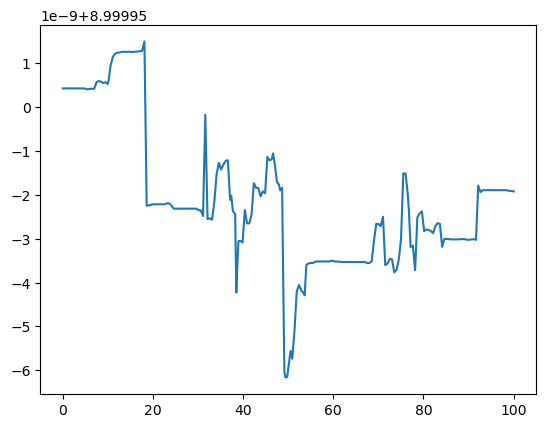

In [17]:
def energy(y):
    phi1, phi2, w1, w2 = y.T
    T = 0.5*(l1**2*(m1+m2)*w1**2 + l2**2*m2*w2**2
              + 2*l1*l2*m2*np.cos(phi1-phi2)*w1*w2)
    V = -g*l1*(m1+m2)*np.cos(phi1) - g*l2*m2*np.cos(phi2)
    return T + V

# Example: near the E1 = E01 + 0.01 regular case from the paper
y0 = [np.pi, np.pi-0.01, 0.0, 0.0]   # small displacement from the (0,0,0,0) fixed point
ts, ys = bulirsch_stoer_integrate(y0, (0, 100), H0=0.02, tol=1e-9)

E = energy(ys)
print(f"Initial energy: {E[0]:.8f}")
print(f"Max energy drift: {np.max(np.abs(E - E[0])):.2e}")
E = energy(ys)
print(f"Initial energy: {E[0]:.8f}")
print(f"Max energy drift: {np.max(np.abs(E - E[0])):.2e}")
plt.plot(ts, E,  '-')

Initial energy: -8.96003332
Max energy drift: 1.48e-12


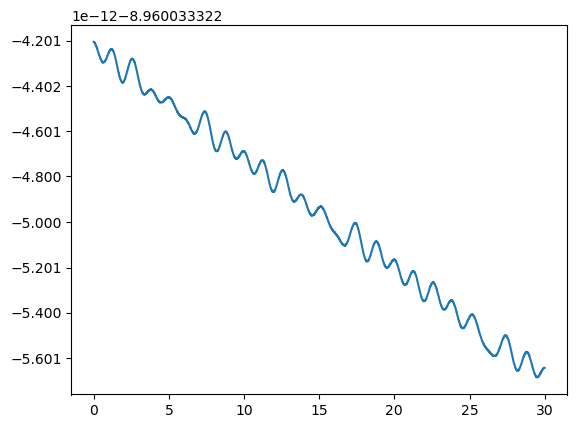

In [18]:
def rk4_integrate(y0, t_span, dt):
    """Classic 4th-order Runge-Kutta, fixed step size dt."""
    t0, tf = t_span
    n_steps = int(np.ceil((tf - t0) / dt))

    ts = np.empty(n_steps + 1)
    ys = np.empty((n_steps + 1, 4))

    t = t0
    y = np.array(y0, dtype=float)
    ts[0] = t
    ys[0] = y

    for i in range(1, n_steps + 1):
        h = min(dt, tf - t)  # last step may be shorter

        k1 = derivatives(t, y)
        k2 = derivatives(t + h/2, y + h/2 * k1)
        k3 = derivatives(t + h/2, y + h/2 * k2)
        k4 = derivatives(t + h,   y + h   * k3)

        y = y + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        t = t + h

        ts[i] = t
        ys[i] = y

    return ts, ys

y0 = [0.1, 0.0, 0.0, 0.0]   # small displacement from the (0,0,0,0) fixed point
ts, ys = rk4_integrate(y0, (0, 30), dt=1e-2)
E = energy(ys)
print(f"Initial energy: {E[0]:.8f}")
print(f"Max energy drift: {np.max(np.abs(E - E[0])):.2e}")
plt.plot(ts, E,  '-')

## Cell 9 — energy-consistent initial conditions on the section surface

Since we sample on φ1=0, it's natural to pick points directly on that surface (φ2, ω2) and solve for ω1 from the energy constraint (quadratic in ω1), rather than searching for them.

In [19]:
def omega1_from_energy(phi2, w2, E, positive=True):
    """On the section phi1=0: solve E = T+V for omega1, given phi2, w2, E.
    Returns None if this (phi2, w2, E) combination is inaccessible."""
    a = 0.5 * l1**2 * (m1 + m2)
    b = l1 * l2 * m2 * np.cos(phi2) * w2       # cos(phi1-phi2) at phi1=0 -> cos(-phi2)=cos(phi2)
    c = 0.5 * l2**2 * m2 * w2**2 - g*l1*(m1+m2) - g*l2*m2*np.cos(phi2) - E

    disc = b**2 - 4*a*c
    if disc < 0:
        return None
    sq = np.sqrt(disc)
    root = (-b + sq) / (2*a) if positive else (-b - sq) / (2*a)
    return root if (root > 0) == positive else None

# Cell 10 event-based integration to collect section points

In [20]:
def trigger_channel(t, y):
    return y[0]  # phi1
trigger_channel.direction = 1   # only phi1 increasing through 0 => omega1 > 0

def trace_orbit(phi2_0, w2_0, E, t_max, max_events=400):
    w1_0 = omega1_from_energy(phi2_0, w2_0, E, positive=True)
    if w1_0 is None:
        return np.array([]), np.array([])

    y0 = [0.0, phi2_0, w1_0, w2_0]

    sol = solve_ivp(derivatives, (0, t_max), y0, method='DOP853',
                     events=trigger_channel, rtol=1e-8, atol=1e-10)

    if sol.t_events[0].size == 0:
        return np.array([]), np.array([])

    pts = sol.y_events[0][:max_events]
    return pts[:, 1], pts[:, 3]

## build and plot a Poincaré section for a chosen energy

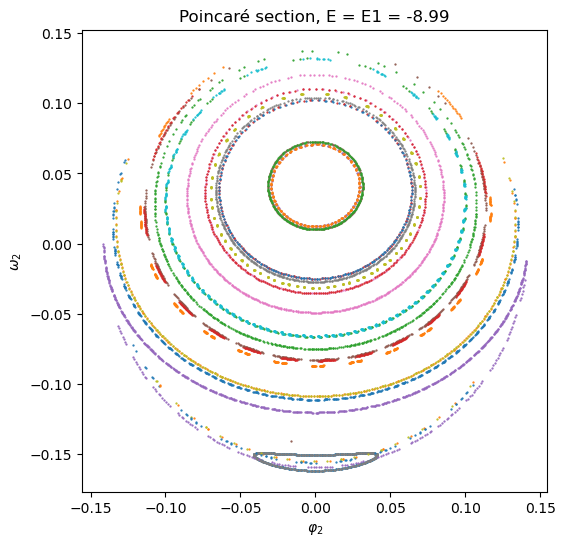

In [43]:
def poincare_section_by_orbit_parallel(E, phi2_range, w2_range, n_grid=8,
                                        t_max=2000, max_events=800, n_jobs=-1):
    """Параллельная версия: каждая начальная точка считается в отдельном процессе."""
    grid = [(p2, w2) for p2 in np.linspace(*phi2_range, n_grid)
                      for w2 in np.linspace(*w2_range, n_grid)]
    results = Parallel(n_jobs=n_jobs)(
        delayed(trace_orbit)(p2, w2, E, t_max, max_events) for p2, w2 in grid
    )
    return [(p2, w2) for p2, w2 in results if p2.size > 0]

E01, E02, E03, E04 = -9, -7, 7, 9
E1 = E01 + 0.01

orbits = poincare_section_by_orbit(E1, phi2_range=(-0.15, 0.15),
                                    w2_range=(-0.15, 0.15), n_grid=8,
                                    t_max=2000, max_events=800)

plt.figure(figsize=(6, 6))
for p2, w2 in orbits:
    plt.plot(p2, w2, '.', markersize=1.2)   # NOTE: markers only, no connecting line
plt.xlabel(r'$\varphi_2$')
plt.ylabel(r'$\omega_2$')
plt.title(f'Poincaré section, E = E1 = {E1:.2f}')
plt.show()

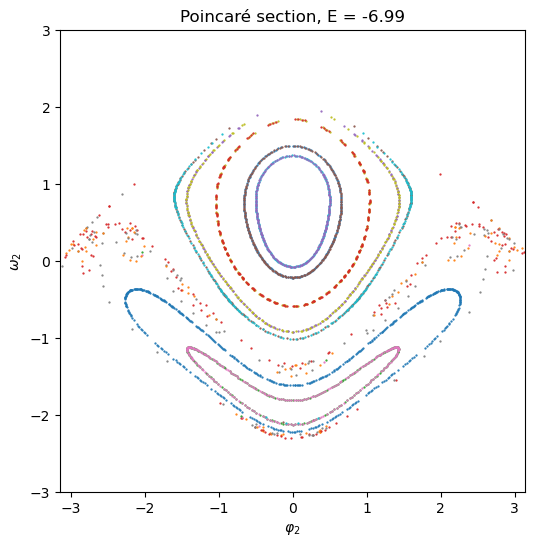

CPU times: total: 312 ms
Wall time: 13.3 s


In [45]:
%%time
E01, E02, E03, E04 = -9, -7, 7, 9
E = E02 + 0.01

orbits = poincare_section_by_orbit_parallel(E, phi2_range=(-np.pi, np.pi),
                                             w2_range=(-3, 3), n_grid=8,
                                             t_max=2000, max_events=800)

plt.figure(figsize=(6, 6))
for p2, w2 in orbits:
    plt.plot(p2, w2, '.', markersize=1.2)
plt.xlabel(r'$\varphi_2$')
plt.xlim(-np.pi, np.pi)
plt.ylim(-3, 3)
plt.ylabel(r'$\omega_2$')
plt.title(f'Poincaré section, E = {E:.2f}')
plt.show()

## Cell 12 — bifurcation diagram machinery

The physical picture: for a fixed E, pick one representative orbit, integrate it a long time, and record φ2 every time the second arm momentarily stops swinging outward (ω2=0, turning around). A regular orbit gives just a few repeating maxima (a stable band); a chaotic orbit gives maxima scattered densely over a range — exactly like a logistic-map bifurcation diagram, but with a mechanical system instead of an iterated map.

In [24]:
def initial_condition(E):
    """Reference orbit: start at phi1=phi2=0, omega2=0, all KE in omega1.
    Valid for E >= E01."""
    V0 = -g*l1*(m1+m2) - g*l2*m2  # potential at phi1=phi2=0, equals E01
    KE = E - V0
    if KE < 0:
        return None
    w1_0 = np.sqrt(2*KE / (l1**2*(m1+m2)))
    return np.array([0.0, 0.0, w1_0, 0.0])

def omega2_zero_falling(t, y):
    return y[3]
omega2_zero_falling.direction = -1   # omega2 decreasing through 0 -> local max of phi2

def bifurcation_points(E, t_max=500, skip_transient=5):
    """Returns the phi2 values at each local maximum, for one energy E."""
    y0 = initial_condition(E)
    if y0 is None:
        return np.array([])
    sol = solve_ivp(derivatives, (0, t_max), y0, method='DOP853',
                     events=omega2_zero_falling, rtol=1e-8, atol=1e-10)
    if sol.t_events[0].size <= skip_transient:
        return np.array([])
    return sol.y_events[0][skip_transient:, 1]   # phi2 column

## Cell 13 — sweep E and plot


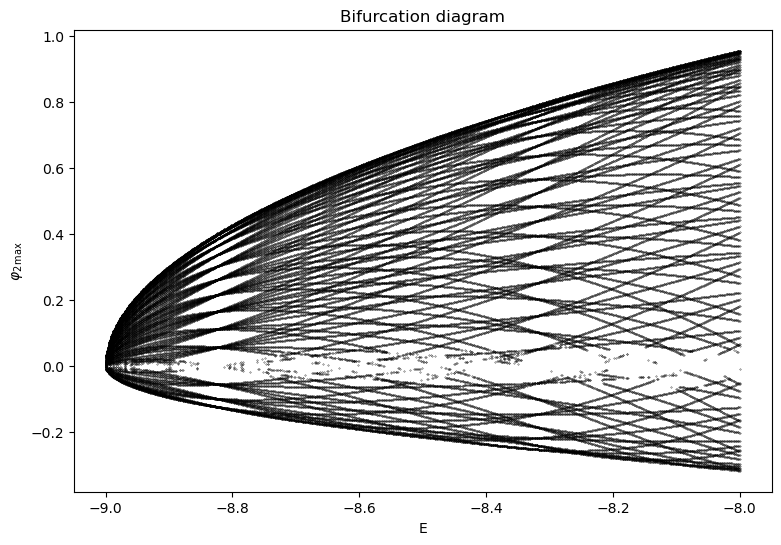

CPU times: total: 3.42 s
Wall time: 1min 14s


In [47]:
%%time
from joblib import Parallel, delayed

E_values = np.linspace(-9.1 , -8.0, 1000)  # matches Fig. 5's range roughly


def _worker(E, t_max=500, skip_transient=5):
    pts = bifurcation_points(E, t_max=t_max, skip_transient=skip_transient)
    return E, pts

results = Parallel(n_jobs=-1)(delayed(_worker)(E) for E in E_values)

E_plot, phi2max_plot = [], []
for E, pts in results:
    E_plot.extend([E] * len(pts))
    phi2max_plot.extend(pts)

plt.figure(figsize=(9, 6))
plt.plot(E_plot, phi2max_plot, '.', markersize=0.5, color='black')
plt.xlabel('E')
plt.ylabel(r'$\varphi_{2\,\mathrm{max}}$')
plt.title('Bifurcation diagram')
plt.show()    

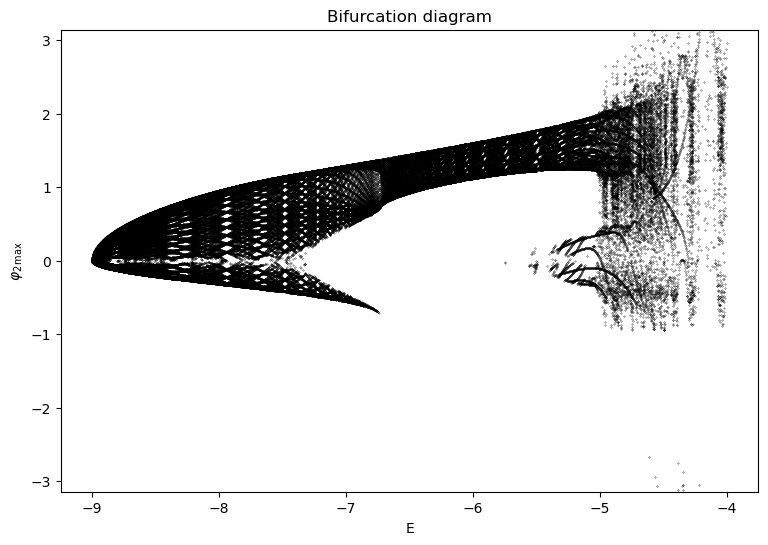

CPU times: total: 7.58 s
Wall time: 3min 26s


In [48]:
%%time
E_values = np.linspace(-9.1 , -4.0, 2000)  # matches Fig. 5's range roughly

def _worker(E, t_max=500, skip_transient=5):
    pts = bifurcation_points(E, t_max=t_max, skip_transient=skip_transient)
    return E, pts

results = Parallel(n_jobs=-1)(delayed(_worker)(E) for E in E_values)

E_plot, phi2max_plot = [], []
for E, pts in results:
    E_plot.extend([E] * len(pts))
    phi2max_plot.extend(pts)

plt.figure(figsize=(9, 6))
plt.plot(E_plot, phi2max_plot, '.', markersize=0.5, color='black')
plt.xlabel('E')
plt.ylim(-np.pi, np.pi)
plt.ylabel(r'$\varphi_{2\,\mathrm{max}}$')
plt.title('Bifurcation diagram')
plt.show() 

# Lyapunov

## Cell 14 — the paper's method: largest Lyapunov exponent only (Eq. 5)


In [49]:
def largest_lyapunov(y0, E_check, t_max=1000, dt_renorm=1.0, d0=1e-8):
    """Wolf et al. two-trajectory method, as used in the paper (Eq. 5)."""
    y_ref = np.array(y0, dtype=float)
    perturbation = np.random.randn(4)
    perturbation *= d0 / np.linalg.norm(perturbation)
    y_pert = y_ref + perturbation

    n_steps = int(t_max / dt_renorm)
    log_sum = 0.0
    chi_history = []

    for i in range(n_steps):
        sol_ref = solve_ivp(derivatives, (0, dt_renorm), y_ref, method='DOP853',
                             rtol=1e-10, atol=1e-12)
        sol_pert = solve_ivp(derivatives, (0, dt_renorm), y_pert, method='DOP853',
                              rtol=1e-10, atol=1e-12)
        y_ref = sol_ref.y[:, -1]
        y_pert = sol_pert.y[:, -1]

        d = y_pert - y_ref
        dist = np.linalg.norm(d)
        log_sum += np.log(dist / d0)

        # renormalize
        y_pert = y_ref + d * (d0 / dist)

        chi_history.append(log_sum / ((i+1) * dt_renorm))

    return np.array(chi_history)

## Cell 15 — full Lyapunov spectrum via Benettin's QR algorithm


In [50]:
def build_jacobian():
    """Returns a fast numpy function J(phi1, phi2, w1, w2) -> 4x4 matrix,
    derived symbolically for exactness (matches derivatives() precisely)."""
    m1s, l1s = 3, 2   # baked in for these parameters
    phi1s, phi2s, w1s, w2s = sp.symbols('phi1 phi2 w1 w2')
    dphi = phi1s - phi2s
    c, s = sp.cos(dphi), sp.sin(dphi)
    denom = m1s + s**2
    dw1 = (-s*(l1s*c*w1s**2 + w2s**2))/(l1s*denom) - ((1+2*m1s)*sp.sin(phi1s)+sp.sin(phi1s-2*phi2s))/(2*l1s*denom)
    dw2 = s*((1+m1s)*(sp.cos(phi1s)+l1s*w1s**2)+c*w2s**2)/denom
    f = sp.Matrix([w1s, w2s, dw1, dw2])
    y = sp.Matrix([phi1s, phi2s, w1s, w2s])
    J = sp.simplify(f.jacobian(y))
    return sp.lambdify((phi1s, phi2s, w1s, w2s), J, 'numpy')

jac_func = build_jacobian()

def variational_rhs(t, state):
    """state = [y (4), Y (16) flattened] -> [dy/dt, dY/dt]"""
    y = state[:4]
    Y = state[4:].reshape(4, 4)
    dy = derivatives(t, y)
    J = np.array(jac_func(*y))
    dY = J @ Y
    return np.concatenate([dy, dY.flatten()])

def lyapunov_spectrum(y0, t_max=1000, dt_renorm=1.0):
    """Benettin's algorithm: propagate 4 deviation vectors, QR-renormalize
    periodically, accumulate log|R_ii|."""
    y = np.array(y0, dtype=float)
    Y = np.eye(4)  # deviation vectors as columns

    n_steps = int(t_max / dt_renorm)
    log_sums = np.zeros(4)
    history = []

    for i in range(n_steps):
        state0 = np.concatenate([y, Y.flatten()])
        sol = solve_ivp(variational_rhs, (0, dt_renorm), state0, method='DOP853',
                         rtol=1e-9, atol=1e-11)
        state_end = sol.y[:, -1]
        y = state_end[:4]
        Y = state_end[4:].reshape(4, 4)

        Q, R = np.linalg.qr(Y)
        diag_R = np.diag(R)
        log_sums += np.log(np.abs(diag_R))
        Y = Q  # renormalized directions for next interval

        t_elapsed = (i + 1) * dt_renorm
        history.append(log_sums / t_elapsed)

    return np.array(history)  # shape (n_steps, 4), converging exponents

## Run for paper's 3 enrgy cases and compare


E1 (E=-8.99): спектр ≈ [ 0.00064093 -0.00072922  0.00091185 -0.00082357], сумма ≈ -0.0000
E2 (E=-7.01): спектр ≈ [ 0.00088936 -0.00044531  0.00053182 -0.00113818], сумма ≈ -0.0002
E3 (E=6.99): спектр ≈ [ 0.13964352  0.04217856  0.00277665 -0.18464618], сумма ≈ -0.0000


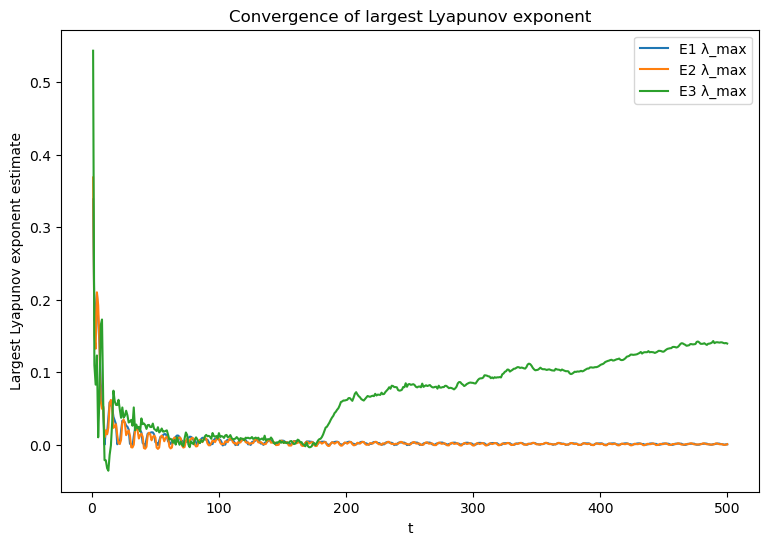

CPU times: total: 22.3 s
Wall time: 22.4 s


In [52]:
%%time
from joblib import Parallel, delayed

E01, E02, E03 = -9.0, -7.0, 7.0
E1, E2, E3 = E01 + 0.01, E02 - 0.01, E03 - 0.01

def _spectrum_worker(label, E, t_max=500, dt_renorm=1.0):
    y0 = ic_for_energy(E)
    hist = lyapunov_spectrum(y0, t_max=t_max, dt_renorm=dt_renorm)
    return label, E, hist

tasks = [('E1', E1), ('E2', E2), ('E3', E3)]
results_list = Parallel(n_jobs=-1)(
    delayed(_spectrum_worker)(label, E) for label, E in tasks
)

results = {}
for label, E, hist in results_list:
    results[label] = hist
    print(f"{label} (E={E:.2f}): спектр ≈ {hist[-1]}, сумма ≈ {hist[-1].sum():.4f}")

plt.figure(figsize=(9, 6))
for label, hist in results.items():
    t_axis = np.arange(1, len(hist)+1)
    plt.plot(t_axis, hist[:, 0], label=f'{label} λ_max')
plt.xlabel('t')
plt.ylabel('Largest Lyapunov exponent estimate')
plt.legend()
plt.title('Convergence of largest Lyapunov exponent')
plt.show()